In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [5]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [6]:
df.drop('customerID', axis=1, inplace=True)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [9]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

In [10]:
print(numeric_features)

print(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [36]:
#Missing Values Check
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
#PREPROCESSING PIPLINE CREATE
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
#Logistic Regression Pipeline
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [16]:
#Hyperparameter Tuning
param_grid_log = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear']
}

In [17]:
#Apply GridSearchCV
grid_log = GridSearchCV(
    log_pipeline,
    param_grid_log,
    cv=5,
    scoring='accuracy'
)

In [18]:
grid_log.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier', LogisticRegression())]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__solver': ['liblinear']},
             scoring='accuracy')

In [19]:
print("Best Parameters:")

print(grid_log.best_params_)

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'liblinear'}


In [20]:
#PREDICTION
y_pred_log = grid_log.predict(X_test)

In [21]:
print("Accuracy:")

print(accuracy_score(y_test, y_pred_log))

Accuracy:
0.8211497515968772


In [22]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [23]:
#Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [24]:
#Random Forest Hyperparameter Tuning
param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10]
}

In [25]:
grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

In [26]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier())]),
             param_grid={'classifier__max_depth': [5, 10],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy')

In [27]:
y_pred_rf = grid_rf.predict(X_test)

In [28]:
print("Random Forest Accuracy:")

print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.8055358410220014


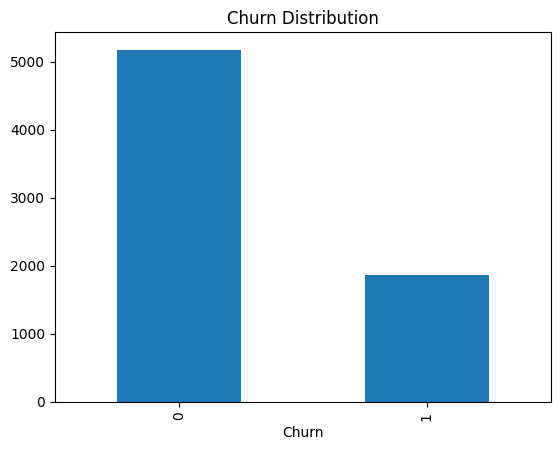

In [38]:
df['Churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")

plt.show()

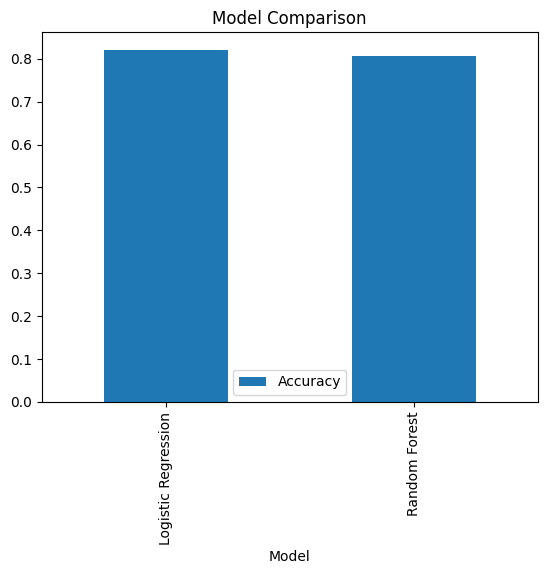

In [40]:
#Model Accuracy Graph
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_acc, rf_acc]
})

comparison.plot(x='Model', y='Accuracy', kind='bar')

plt.title("Model Comparison")

plt.show()

In [41]:
#Feature Importance
best_rf = grid_rf.best_estimator_

feature_importance = best_rf.named_steps['classifier'].feature_importances_

print(feature_importance)

[0.0109258  0.14085464 0.09545061 0.12528567 0.01027569 0.01033556
 0.01060889 0.01002711 0.00961521 0.00944556 0.00434119 0.00323691
 0.00963259 0.00378672 0.00961724 0.01635219 0.03644633 0.00741052
 0.04875079 0.00410905 0.01722262 0.01645337 0.00376226 0.01111649
 0.01482727 0.00398255 0.00818273 0.04438276 0.00544229 0.01385263
 0.00780719 0.00592123 0.00913783 0.00987812 0.00446812 0.0098391
 0.08828782 0.01928454 0.03830121 0.01297871 0.01208584 0.00885474
 0.00977202 0.03820958 0.00944071]


In [34]:
sample_customer = X_test.iloc[:1]

prediction = loaded_model.predict(sample_customer)

print(prediction)

[1]


In [35]:
if prediction[0] == 1:
    print("Customer will churn")
else:
    print("Customer will stay")

Customer will churn


In [31]:
#Saved Model Load
loaded_model = joblib.load('churn_pipeline.pkl')

In [32]:
prediction = loaded_model.predict(X_test)

print(prediction)

[1 0 0 ... 0 0 0]
